In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
from convex_map import generate_map
from map_visualization import _bounce_angle, animate_camera_rotation, visualize_map_at_time
import Dynamic
import importlib
from Camera import Camera
importlib.reload(Dynamic)
from Dynamic import DynamicMap

Proof-of-Concept Testcase for hybrid model strategy

In [2]:
# Hybrid Model
# Mode 1: Slient & Slow
# Mode 2: Nominal
# Mode 3: Fast & Noisy
# Mode 1 <-> Mode 2 <-> Mode 3

v_modes = [1.0, 5.0, 10.0]
n_modes = [1.0, 25.0, 100.0]

In [3]:
# Import path data
with open("json/ad_game/optimized_attacker_path.json", "r") as file:
    attacker_path = json.load(file)
    
print(attacker_path)

{'x': [[0.0, 0.0015283651442652584, 0.0015302279844870027, 0.0015302333073783968, 0.0015302333152649693, 0.0015302333152746304, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412, 0.0015302333152746412

(<Figure size 600x600 with 1 Axes>,
 <AxesSubplot: title={'center': 'Operation Map @ t = 0.00'}>)

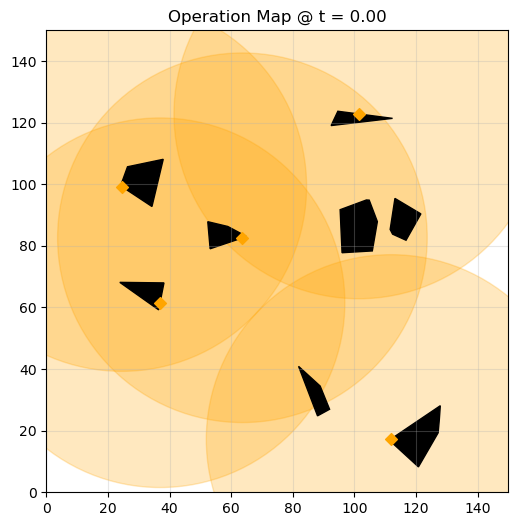

In [4]:
map_size = (150, 150)
num_buildings = 8
num_direc_sensor = 0
num_omni_sensor = 5
num_sensors = num_direc_sensor + num_omni_sensor
fov_half_rad = np.deg2rad(15)
max_range = 60
panspeed_range = (np.deg2rad(-10), np.deg2rad(10))
cam_period = 200
cam_increment = 0.2
rng_seed = 286

# Generate map
map_in, cam_dict = generate_map(
    map_size= map_size,
    num_buildings= num_buildings,
    num_directional_sensors= num_direc_sensor,
    num_omni_sensors= num_omni_sensor,
    fov_half_rad= fov_half_rad,
    max_range= max_range,
    fov_half_rad_omni= fov_half_rad,
    max_range_omni= max_range/2,
    panspeed_range= panspeed_range,
    cam_period= cam_period,
    cam_increment= cam_increment,
    rng_seed= rng_seed,
    balanced_sensors= False,
    param_lambda= [0.5, 0.5],
    param_beta= [0.4, 0.25]
)

x0 = [0, 0, 0]
xf = [150, 150, 360]
vmax = 10

# Parse map_in dictionary
map_size = map_in['st']['size']
# Generate Dynamic Map
dmap = DynamicMap(map_in, cam_dict)
map_in['dy'] = dmap

# Vehicle Spec
vehicle = {}
vehicle['v'] = vmax
vehicle['radius'] = 1

visualize_map_at_time(map_in, cam_dict, t=0, sensor_alpha=0.5)

In [5]:
# Parse into N different segments
def divide_chunks(l, n):
    # Calculate the size of each chunk
    k, m = divmod(len(l), n)
    return [l[i*k + min(i, m):(i+1)*k + min(i+1, m)] for i in range(n)]

# N partition
N = 10

pos_x = attacker_path['x'][0]
pos_y = attacker_path['y'][0]
time_t = attacker_path['t'][0]
segmented_x = divide_chunks(pos_x, N)
segmented_y = divide_chunks(pos_y, N)
segmented_t = divide_chunks(time_t, N)

In [6]:
# Sensor Model
# Distance decay variable
sigma = 50

# Hybrid Rules (The Guards)
r_mode1 = 30.0
r_mode3 = r_mode1*1.75

v_modes = {1: 1.0, 2: 10.0, 3: 10.0}
n_modes = {1: 10.0, 2: 100.0, 3: 200.0}

sensor_pos = np.vstack((cam_dict['omnidirectional']['x'], cam_dict['omnidirectional']['y']))

In [7]:
def run_simulation(strategy_type="hybrid"):
    total_risk = 0
    total_time = 0
    total_dist = 0
    
    logs = {"x": [], "y": [], "v": [], "risk": [], "mode": [], "t": [], 'dist_2_sensors': []}
    
    for i in range(len(pos_x)-1):
        xi = pos_x[i]
        yi = pos_y[i]
        ti = time_t[i]
        
        # 1. Sense min distance to threats
        dist_2_sensors = []
        for si in range(cam_dict['n']):
            dist_2_sensors.append(np.sqrt((xi-sensor_pos[0][si])**2 + (yi-sensor_pos[1][si])**2))
        
        # 2. Determine Mode
        if strategy_type == "hybrid":
            # If attacker is in range of any sensor:
            if any(dist_2_sensors[sj] < r_mode1 for sj in range(cam_dict['n'])):
                mode = 1            
            elif all(dist_2_sensors[sj] > r_mode3 for sj in range(cam_dict['n'])):
                mode = 3
            else:
                mode = 2
        else:
            # Baseline: Constant Nominal Speed
            mode = 2
            
        v = v_modes[mode]
        noise = n_modes[mode]
        
        # 3. Calculate instantaneous risk
        # Sum of risks from all sensors
        current_risk_val = sum([noise/sigma*np.exp(-np.sqrt((xi-sensor_pos[0][si])**2 + (yi-sensor_pos[1][si])**2)) for si in range(cam_dict['n'])])
        
        # 4. Log and Update
        if i > 0:# and strategy_type == 'hybrid':
            passed_time = np.sqrt((xi-logs['x'][-1])**2+(yi-logs['y'][-1])**2)/v
            logs["t"].append(passed_time)
            total_time += passed_time
        
        logs["x"].append(xi)
        logs['y'].append(yi)
        logs["v"].append(v)
        logs["risk"].append(current_risk_val)
        logs["mode"].append(mode)
        
        # elif i > 0 and strategy_type == 'baseline':
        #     total_dist += np.sqrt((xi-logs['x'][-2])**2+(yi-logs['y'][-2])**2)
        #     total_time = total_dist/v
        logs['dist_2_sensors'].append(dist_2_sensors)
        # total_risk += current_risk_val*(segmented_t[i][-1]-segmented_t[i][0])
        
    return logs, total_time, total_dist

# Run both
hybrid_logs, hybrid_time, hybrid_dist = run_simulation("hybrid")
base_logs, base_time, base_dist = run_simulation("baseline")

# --- Results Table ---
print(f"{'Strategy':<15} | {'Detection Costs':<12} | {'Time Cost':<12}")
print("-" * 45)
print(f"{'Baseline':<15} | {np.mean(base_logs['risk']):<12.4f} | {base_time:<12.4f}")
print(f"{'Hybrid':<15} | {np.mean(hybrid_logs['risk']):<12.4f} | {hybrid_time:<12.4f}")

Strategy        | Detection Costs | Time Cost   
---------------------------------------------
Baseline        | 0.0000       | 23.9458     
Hybrid          | 0.0000       | 50.7179     


In [8]:
print(time_t[-1])

37.18364745132844


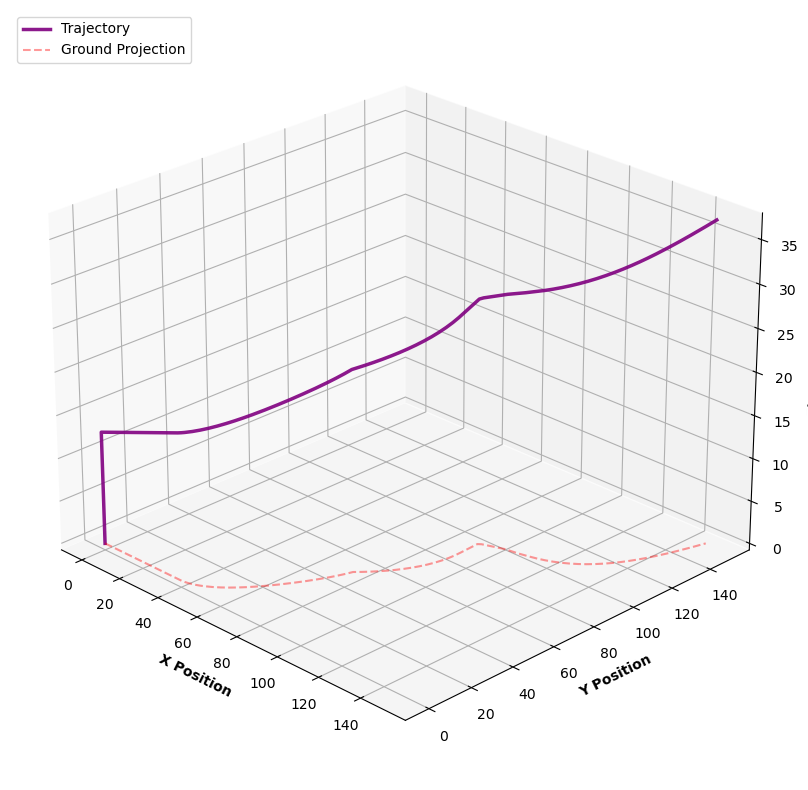

In [12]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 1. Plot the main 3D Path
ax.plot(pos_x, pos_y, time_t, '-', c='purple', linewidth=2.5, alpha=0.9, label='Trajectory')

# 2. Plot the "Shadow" on the floor (Z=0 or min time)
# This provides spatial context to see where the path is relative to the ground
min_t = min(time_t)
ax.plot(pos_x, pos_y, [min_t]*len(pos_x), '--', c='r', alpha=0.4, label='Ground Projection')

# 3. Enhance the View & Aesthetics
ax.set_xlabel('X Position', fontweight='bold')
ax.set_ylabel('Y Position', fontweight='bold')
ax.set_zlabel('Time (s)', fontweight='bold')
# ax.set_title('Sensor Path Analysis', fontsize=14, pad=20)

# Adjust the pane colors to make it look cleaner
ax.xaxis.pane.set_edgecolor('white')
ax.yaxis.pane.set_edgecolor('white')
ax.zaxis.pane.set_edgecolor('white')
ax.grid(True, linestyle='--', alpha=0.5)

# 4. Set the initial viewing angle for better depth
ax.view_init(elev=25, azim=-45)

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
fig.savefig('traj.png', dpi=300, bbox_inches='tight')

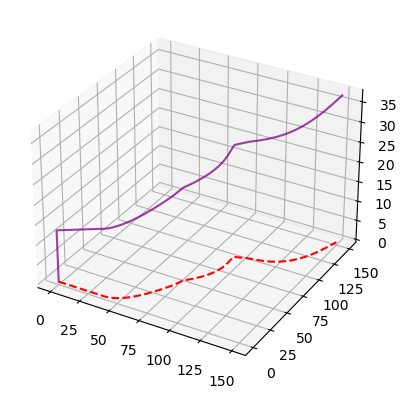

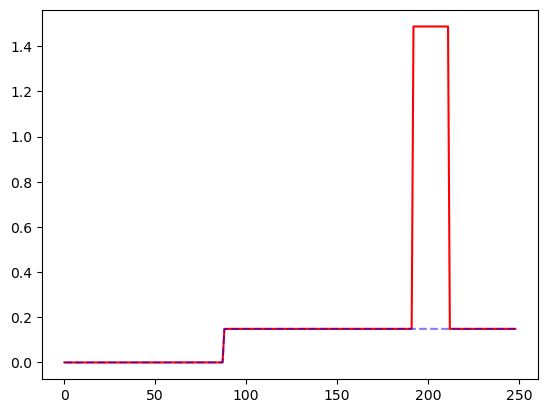

In [10]:
# fig = plt.figure()
# iteration = np.linspace(0, len(hybrid_logs['mode'])-1, len(hybrid_logs['mode']))
# plt.plot(iteration, hybrid_logs['mode'], '-r')
iteration = np.linspace(0, len(hybrid_logs['mode'])-2, len(hybrid_logs['mode'])-1)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(pos_x, pos_y, time_t, '-', c='purple', alpha=0.75)
ax.plot(pos_x, pos_y, '--', c='r')

fig = plt.figure()
plt.plot(iteration, hybrid_logs['t'], '-r')
plt.plot(iteration, base_logs['t'], '--b', alpha=0.5)